# Frequency- and time-frequency-domain source-space analysis

[under construction]

## Loading data

We will begin by loading the sample data and extracting epochs corresponding to auditory stimuli presented to the left versus right ear.

In [70]:
import numpy as np
import mne
from mne.datasets import sample
from mne.time_frequency import csd_morlet
from mne.beamformer import make_dics, apply_dics_csd
import mne_plsc

data_path = sample.data_path()
meg_path = data_path / "MEG" / "sample"
fname_raw = meg_path / "sample_audvis_filt-0-40_raw.fif"
fname_event = meg_path / "sample_audvis_filt-0-40_raw-eve.fif"

# Load data
raw = mne.io.read_raw_fif(fname_raw)
events = mne.read_events(fname_event)

# pick MEG channels
picks = mne.pick_types(
    raw.info, meg=True, eeg=False, stim=False, eog=True, exclude="bads"
)
# Read epochs
epochs = mne.Epochs(
    raw,
    events,
    event_id={'left': 1, 'right': 2},
    tmin=-1, tmax=2,
    picks=picks,
    baseline=(None, 0),
    reject=dict(eog=150e-6),
    preload=True,
    verbose=False
)

Opening raw data file C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


## 

In [71]:
fname_fwd = meg_path / "sample_audvis-eeg-oct-6-fwd.fif"
fname_fwd = meg_path / "sample_audvis-meg-vol-7-fwd.fif"
fwd = mne.read_forward_solution(fname_fwd)
freqs = np.logspace(np.log10(15), np.log10(30), 3)
csd = csd_morlet(epochs, freqs, decim=1, n_cycles=1.5)
csd_baseline = csd_morlet(epochs, freqs, tmin=-1, tmax=0, decim=1, n_cycles=1.5)
dics = make_dics(
    epochs.info,
    fwd,
    csd,
    noise_csd=csd_baseline,
    pick_ori="max-power",
    reduce_rank=True,
    real_filter=True,
    verbose=False
)

Reading forward solution from C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis-meg-vol-7-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (3757 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Computing cross-spectral density from epochs...


  0%|          | CSD epoch blocks : 0/82 [00:00<?,       ?it/s]

[done]
Computing cross-spectral density from epochs...


  0%|          | CSD epoch blocks : 0/82 [00:00<?,       ?it/s]

[done]


In [72]:
stcs = []
for epoch_idx in range(len(epochs)):
    print(epoch_idx)
    epoch = epochs[epoch_idx]
    # Baseline CSD
    csd = csd_morlet(epoch, freqs, tmin=0, tmax=1, decim=20, verbose=False)
    stc, _ = apply_dics_csd(csd, dics, verbose=False)
    stcs.append(stc)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81


In [ ]:
labels = mne_plsc.utils.get_epoch_labels(epochs)

In [80]:
res = mne_plsc.fit_mc(data=stcs,
                      between=labels,
                      source_domain='freq',
                      source_freqs=freqs)

In [81]:
res.permute(100)
print(res.summary())

Permuting: 100%|██████████████████████████████████████████████████████████████████████████████████| 100/100 [01:09<00:00,  1.44it/s]

   LV index  singular value  variance explained   p value
0         0      186.767656                 1.0  0.613861
1         1        0.000000                 0.0       NaN


Resampling: 100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 102.13it/s]

-- number of adjacent vertices : 3757


Clustering z-scores
Computing clusters for lv_idx 0...
63 clusters


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

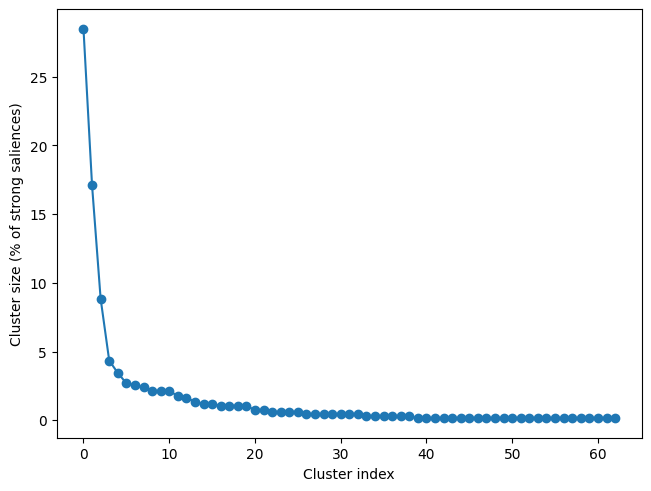

In [76]:
res.bootstrap(100)
res.add_source_info(src=fwd['src'],
                    mri=data_path / 'subjects' / 'sample' / 'mri' / 'T1.mgz')
res.add_adjacency()
res.cluster()
res.plot_cluster_sizes(0)

(<Figure size 640x480 with 5 Axes>, <Axes: >)

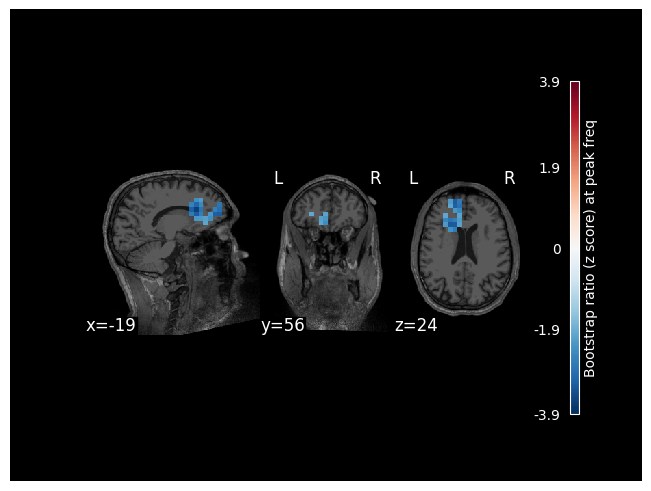

In [77]:
res.plot_cluster_spatial(0, 2)

In [78]:
fname_inv = meg_path / "sample_audvis-meg-vol-7-meg-inv.fif"
inverse_operator = read_inverse_operator(fname_inv, verbose=False)

snr = 3.0
lambda2 = 1.0 / snr**2
stcs = apply_inverse_epochs(
    epochs=epochs,
    inverse_operator=inverse_operator,
    lambda2=lambda2,
    method='dSPM',
    verbose=False
)

In [79]:
# Paths to forward operator and FreeSurfer subject directory
fname_fwd = (
    data_path / "derivatives" / f"sub-{subject}" / f"sub-{subject}_task-{task}-fwd.fif"
)
subjects_dir = data_path / "derivatives" / "freesurfer" / "subjects"
# Set frequencies
freqs = np.logspace(np.log10(12), np.log10(30), 10)
# Get cross-spectral density during baseline and trial periods
csd = csd_morlet(epochs, freqs, tmin=-1, tmax=1.5, decim=20)
csd_baseline = csd_morlet(epochs, freqs, tmin=-1, tmax=0, decim=20)
fwd = mne.read_forward_solution(fname_fwd)
dics = make_dics(
    epochs.info,
    fwd,
    csd,
    noise_csd=csd_baseline,
    pick_ori="max-power",
    reduce_rank=True,
    real_filter=True,
)

NameError: name 'subject' is not defined

## Apply DICS beamformer

In [ ]:
stcs = []
labels = []
for epoch_idx in range(len(epochs)):
    epoch = epochs[epoch_idx]
    # Baseline CSD
    csd_baseline = csd_morlet(epoch, freqs, tmin=-1, tmax=0, decim=20)
    src_baseline, freqs = apply_dics_csd(csd_baseline, dics)
    stcs.append(src_baseline)
    labels.append('baseline')
    csd_trial = csd_morlet(epoch, freqs, tmin=0.5, tmax=1.5, decim=20)
    src_trial, freqs = apply_dics_csd(csd_trial, dics)
    stcs.append(src_trial)
    labels.append('trial')